# Bulk coarse-grained dataset inventory

## Purpose

This notebook investigates the supplied `CG_field_phi_bulk` dataset before
any reduced-order modelling is attempted.

The immediate objectives are to:

1. identify every bulk-data file and extract its particle-size ratio;
2. compare the bulk parameter sequence with the existing small-field dataset;
3. inspect the raw MercuryCG file structure;
4. determine the grid dimensions, columns and memory requirements;
5. check whether the bulk files can be paired one-to-one with the small-field
   simulations;
6. prepare a validated inventory for later preprocessing.

No POD basis or surrogate model is fitted in this notebook until the raw-data
structure has been verified.

In [4]:
from pathlib import Path
import re
import sys

import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    """Locate the repository root."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "data").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "results").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

RAW_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
)

BULK_DATA_DIR = (
    RAW_DATA_DIR
    / "CG_field_phi_bulk"
)

SMALL_DATA_DIR = (
    RAW_DATA_DIR
    / "CG_field_phi_small"
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for required_directory in [
    BULK_DATA_DIR,
    SMALL_DATA_DIR,
]:
    if not required_directory.exists():
        raise FileNotFoundError(
            f"Required directory was not found:\n"
            f"{required_directory}"
        )


standard_filename_pattern = re.compile(
    r"rotating_drum_bidisperse_"
    r"size_ratio_"
    r"(?P<integer>\d+)_"
    r"(?P<fraction>\d+)_"
    r"num_"
    r"(?P<simulation_number>\d+)"
    r"\.stat"
)


def parse_standard_filename(
    file_path: Path,
) -> dict:
    """Extract parameter information from a standard filename."""
    match = standard_filename_pattern.fullmatch(
        file_path.name
    )

    if match is None:
        raise ValueError(
            "Filename does not match the standard format: "
            f"{file_path.name}"
        )

    integer_part = match.group(
        "integer"
    )

    fractional_part = match.group(
        "fraction"
    )

    size_ratio = float(
        f"{integer_part}.{fractional_part}"
    )

    return {
        "size_ratio": size_ratio,
        "simulation_number": int(
            match.group(
                "simulation_number"
            )
        ),
    }


bulk_files = sorted(
    file_path
    for file_path in BULK_DATA_DIR.glob(
        "*.stat"
    )
    if standard_filename_pattern.fullmatch(
        file_path.name
    )
)

small_files = sorted(
    file_path
    for file_path in SMALL_DATA_DIR.glob(
        "*.stat"
    )
    if standard_filename_pattern.fullmatch(
        file_path.name
    )
)

print("Python executable:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Bulk-data directory:", BULK_DATA_DIR)
print("Small-data directory:", SMALL_DATA_DIR)

print(
    "\nStandard bulk files:",
    len(bulk_files),
)

print(
    "Standard small files:",
    len(small_files),
)

assert len(bulk_files) == 100
assert len(small_files) == 100

print("\nFile-discovery checks passed.")

Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Project root: /Users/rallen/Documents/msc-rom-particle-systems
Bulk-data directory: /Users/rallen/Documents/msc-rom-particle-systems/data/raw/CG_field_phi_bulk
Small-data directory: /Users/rallen/Documents/msc-rom-particle-systems/data/raw/CG_field_phi_small

Standard bulk files: 100
Standard small files: 100

File-discovery checks passed.


In [5]:
def build_file_inventory(
    files: list[Path],
    dataset_name: str,
) -> pd.DataFrame:
    """Create one inventory row per standard simulation file."""
    records = []

    for file_path in files:
        metadata = parse_standard_filename(
            file_path
        )

        records.append(
            {
                "dataset": dataset_name,
                "size_ratio": metadata[
                    "size_ratio"
                ],
                "simulation_number": metadata[
                    "simulation_number"
                ],
                "filename": file_path.name,
                "file_size_bytes": (
                    file_path.stat().st_size
                ),
                "file_size_mb": (
                    file_path.stat().st_size
                    / 1024**2
                ),
                "path": str(file_path),
            }
        )

    return (
        pd.DataFrame(records)
        .sort_values(
            [
                "size_ratio",
                "simulation_number",
            ]
        )
        .reset_index(
            drop=True
        )
    )


bulk_inventory = build_file_inventory(
    bulk_files,
    "bulk",
)

small_inventory = build_file_inventory(
    small_files,
    "small",
)

bulk_parameters = bulk_inventory[
    "size_ratio"
].to_numpy()

small_parameters = small_inventory[
    "size_ratio"
].to_numpy()

bulk_simulation_numbers = bulk_inventory[
    "simulation_number"
].to_numpy()

small_simulation_numbers = small_inventory[
    "simulation_number"
].to_numpy()

print("Bulk inventory summary")
print("----------------------")

print(
    "Number of files:",
    len(bulk_inventory),
)

print(
    "Parameter range:",
    f"{bulk_parameters.min():.6f}",
    "to",
    f"{bulk_parameters.max():.6f}",
)

print(
    "Simulation-number range:",
    bulk_simulation_numbers.min(),
    "to",
    bulk_simulation_numbers.max(),
)

print(
    "Total bulk size:",
    f"{bulk_inventory['file_size_mb'].sum():.2f} MB",
)

print(
    "Mean bulk-file size:",
    f"{bulk_inventory['file_size_mb'].mean():.3f} MB",
)

print(
    "Minimum bulk-file size:",
    f"{bulk_inventory['file_size_mb'].min():.3f} MB",
)

print(
    "Maximum bulk-file size:",
    f"{bulk_inventory['file_size_mb'].max():.3f} MB",
)


parameters_match = np.allclose(
    bulk_parameters,
    small_parameters,
    rtol=0.0,
    atol=1e-12,
)

simulation_numbers_match = np.array_equal(
    bulk_simulation_numbers,
    small_simulation_numbers,
)

filenames_match = np.array_equal(
    bulk_inventory[
        "filename"
    ].to_numpy(),
    small_inventory[
        "filename"
    ].to_numpy(),
)

print("\nBulk-small pairing checks")
print("-------------------------")

print(
    "Parameters match:",
    parameters_match,
)

print(
    "Simulation numbers match:",
    simulation_numbers_match,
)

print(
    "Filenames match:",
    filenames_match,
)

assert bulk_inventory[
    "size_ratio"
].is_unique

assert small_inventory[
    "size_ratio"
].is_unique

assert parameters_match
assert simulation_numbers_match
assert filenames_match

paired_inventory = pd.DataFrame(
    {
        "size_ratio": bulk_parameters,
        "simulation_number": (
            bulk_simulation_numbers
        ),
        "small_filename": small_inventory[
            "filename"
        ],
        "bulk_filename": bulk_inventory[
            "filename"
        ],
        "small_file_size_mb": small_inventory[
            "file_size_mb"
        ],
        "bulk_file_size_mb": bulk_inventory[
            "file_size_mb"
        ],
        "bulk_to_small_size_ratio": (
            bulk_inventory[
                "file_size_bytes"
            ].to_numpy()
            / small_inventory[
                "file_size_bytes"
            ].to_numpy()
        ),
    }
)

inventory_path = (
    TABLE_DIR
    / "cg_phi_bulk_file_inventory.csv"
)

paired_inventory.to_csv(
    inventory_path,
    index=False,
)

print("\nOne-to-one pairing checks passed.")

print("\nSaved paired inventory:")
print(inventory_path)

display(
    paired_inventory.head(10)
)

Bulk inventory summary
----------------------
Number of files: 100
Parameter range: 1.000000 to 2.000000
Simulation-number range: 1 to 100
Total bulk size: 133.16 MB
Mean bulk-file size: 1.332 MB
Minimum bulk-file size: 1.303 MB
Maximum bulk-file size: 1.404 MB

Bulk-small pairing checks
-------------------------
Parameters match: True
Simulation numbers match: True
Filenames match: True

One-to-one pairing checks passed.

Saved paired inventory:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_bulk_file_inventory.csv


,size_ratio,simulation_number,small_filename,bulk_filename,small_file_size_mb,bulk_file_size_mb,bulk_to_small_size_ratio
0,1.000000,1,rotating_drum_bidisperse_size_ratio_1_000000_n...,rotating_drum_bidisperse_size_ratio_1_000000_n...,1.313623,1.311904,0.998691
1,1.010101,2,rotating_drum_bidisperse_size_ratio_1_010101_n...,rotating_drum_bidisperse_size_ratio_1_010101_n...,1.316404,1.305869,0.991997
2,1.020202,3,rotating_drum_bidisperse_size_ratio_1_020202_n...,rotating_drum_bidisperse_size_ratio_1_020202_n...,1.309952,1.303453,0.995039
3,1.030303,4,rotating_drum_bidisperse_size_ratio_1_030303_n...,rotating_drum_bidisperse_size_ratio_1_030303_n...,1.328001,1.316956,0.991683
4,1.040404,5,rotating_drum_bidisperse_size_ratio_1_040404_n...,rotating_drum_bidisperse_size_ratio_1_040404_n...,1.315114,1.305374,0.992594
5,1.050505,6,rotating_drum_bidisperse_size_ratio_1_050505_n...,rotating_drum_bidisperse_size_ratio_1_050505_n...,1.345098,1.334828,0.992365
6,1.060606,7,rotating_drum_bidisperse_size_ratio_1_060606_n...,rotating_drum_bidisperse_size_ratio_1_060606_n...,1.317795,1.323036,1.003977
7,1.070707,8,rotating_drum_bidisperse_size_ratio_1_070707_n...,rotating_drum_bidisperse_size_ratio_1_070707_n...,1.313852,1.303917,0.992438
8,1.080808,9,rotating_drum_bidisperse_size_ratio_1_080808_n...,rotating_drum_bidisperse_size_ratio_1_080808_n...,1.322234,1.329408,1.005425
9,1.090909,10,rotating_drum_bidisperse_size_ratio_1_090909_n...,rotating_drum_bidisperse_size_ratio_1_090909_n...,1.322944,1.315526,0.994393


In [6]:
def inspect_raw_text_file(
    file_path: Path,
    number_of_lines: int = 12,
) -> None:
    """Print initial lines and basic text-file properties."""
    with file_path.open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as file_handle:
        initial_lines = [
            file_handle.readline().rstrip(
                "\n"
            )
            for _ in range(
                number_of_lines
            )
        ]

    with file_path.open(
        "r",
        encoding="utf-8",
        errors="replace",
    ) as file_handle:
        total_line_count = sum(
            1
            for _ in file_handle
        )

    print("File:", file_path.name)

    print(
        "File size:",
        f"{file_path.stat().st_size / 1024**2:.3f} MB",
    )

    print(
        "Total line count:",
        total_line_count,
    )

    print("\nInitial lines:")

    for line_number, line in enumerate(
        initial_lines,
        start=1,
    ):
        token_count = len(
            line.split()
        )

        print(
            f"{line_number:02d} "
            f"[{token_count:2d} tokens]: "
            f"{line}"
        )


representative_index = 0

representative_bulk_file = bulk_files[
    representative_index
]

representative_small_file = small_files[
    representative_index
]

print("Representative parameter:")
print(
    bulk_inventory.loc[
        representative_index,
        "size_ratio",
    ]
)

print("\n=== BULK FILE ===")
inspect_raw_text_file(
    representative_bulk_file,
)

print("\n=== MATCHING SMALL FILE ===")
inspect_raw_text_file(
    representative_small_file,
)

Representative parameter:
1.0

=== BULK FILE ===
File: rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat
File size: 1.312 MB
Total line count: 10002

Initial lines:
01 [20 tokens]: TimeAveragedCG<XZ> min -33 -5 -33 max 33 5 33 timeMin 1377 n 100 1 100 width 3 Lucy cutoff 3
02 [10 tokens]: time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize 
03 [32 tokens]: 1720.72 -32.67 -32.67 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
04 [32 tokens]: 1720.72 -32.67 -32.01 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
05 [32 tokens]: 1720.72 -32.67 -31.35 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
06 [32 tokens]: 1720.72 -32.67 -30.69 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
07 [32 tokens]: 1720.72 -32.67 -30.03 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
08 [32 tokens]: 1720.72 -32.67 -29.37 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [7]:
def load_stat_matrix(
    file_path: Path,
    usecols=None,
) -> np.ndarray:
    """Load the numerical section of a MercuryCG stat file."""
    matrix = np.loadtxt(
        file_path,
        skiprows=2,
        usecols=usecols,
    )

    if matrix.ndim == 1:
        matrix = matrix.reshape(
            1,
            -1,
        )

    if not np.isfinite(matrix).all():
        raise ValueError(
            f"Non-finite values found in {file_path.name}"
        )

    return matrix


representative_bulk_matrix = load_stat_matrix(
    representative_bulk_file
)

representative_small_matrix = load_stat_matrix(
    representative_small_file
)

print("Representative numerical shapes")
print("--------------------------------")

print(
    "Bulk matrix:",
    representative_bulk_matrix.shape,
)

print(
    "Small matrix:",
    representative_small_matrix.shape,
)

assert representative_bulk_matrix.shape == (
    10000,
    32,
)

assert representative_small_matrix.shape == (
    10000,
    32,
)


bulk_coordinates = (
    representative_bulk_matrix[
        :,
        1:3,
    ]
)

small_coordinates = (
    representative_small_matrix[
        :,
        1:3,
    ]
)

maximum_coordinate_difference = np.max(
    np.abs(
        bulk_coordinates
        - small_coordinates
    )
)

bulk_times = np.unique(
    representative_bulk_matrix[
        :,
        0,
    ]
)

small_times = np.unique(
    representative_small_matrix[
        :,
        0,
    ]
)

x_values = np.unique(
    bulk_coordinates[
        :,
        0,
    ]
)

z_values = np.unique(
    bulk_coordinates[
        :,
        1,
    ]
)

x_spacing = float(
    np.mean(
        np.diff(x_values)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_values)
    )
)

print("\nGrid and time information")
print("-------------------------")

print(
    "Unique bulk times:",
    bulk_times,
)

print(
    "Unique small times:",
    small_times,
)

print(
    "Number of x points:",
    x_values.size,
)

print(
    "Number of z points:",
    z_values.size,
)

print(
    "x range:",
    f"{x_values.min():.6f}",
    "to",
    f"{x_values.max():.6f}",
)

print(
    "z range:",
    f"{z_values.min():.6f}",
    "to",
    f"{z_values.max():.6f}",
)

print(
    "Mean x spacing:",
    f"{x_spacing:.6f}",
)

print(
    "Mean z spacing:",
    f"{z_spacing:.6f}",
)

print(
    "Maximum coordinate difference:",
    f"{maximum_coordinate_difference:.6e}",
)

assert x_values.size == 100
assert z_values.size == 100

assert np.array_equal(
    bulk_times,
    small_times,
)

assert maximum_coordinate_difference < 1e-12

print("\nRepresentative grid checks passed.")

Representative numerical shapes
--------------------------------
Bulk matrix: (10000, 32)
Small matrix: (10000, 32)

Grid and time information
-------------------------
Unique bulk times: [1720.72]
Unique small times: [1720.72]
Number of x points: 100
Number of z points: 100
x range: -32.670000 to 32.670000
z range: -32.670000 to 32.670000
Mean x spacing: 0.660000
Mean z spacing: 0.660000
Maximum coordinate difference: 0.000000e+00

Representative grid checks passed.


In [8]:
representative_bulk_phi = (
    representative_bulk_matrix[
        :,
        3,
    ]
)

representative_small_phi = (
    representative_small_matrix[
        :,
        3,
    ]
)

representative_difference_phi = (
    representative_bulk_phi
    - representative_small_phi
)

cell_area = (
    x_spacing
    * z_spacing
)

bulk_integrated_volume = float(
    representative_bulk_phi.sum()
    * cell_area
)

small_integrated_volume = float(
    representative_small_phi.sum()
    * cell_area
)

difference_integrated_volume = float(
    representative_difference_phi.sum()
    * cell_area
)

active_mask = (
    (np.abs(representative_bulk_phi) > 1e-12)
    | (np.abs(representative_small_phi) > 1e-12)
)

if (
    np.std(
        representative_bulk_phi[
            active_mask
        ]
    ) > 0.0
    and np.std(
        representative_small_phi[
            active_mask
        ]
    ) > 0.0
):
    representative_correlation = float(
        np.corrcoef(
            representative_bulk_phi[
                active_mask
            ],
            representative_small_phi[
                active_mask
            ],
        )[0, 1]
    )
else:
    representative_correlation = np.nan


print("Representative volume-fraction comparison")
print("-----------------------------------------")

print(
    "Bulk minimum:",
    f"{representative_bulk_phi.min():.6e}",
)

print(
    "Bulk maximum:",
    f"{representative_bulk_phi.max():.6e}",
)

print(
    "Bulk mean:",
    f"{representative_bulk_phi.mean():.6e}",
)

print(
    "Small minimum:",
    f"{representative_small_phi.min():.6e}",
)

print(
    "Small maximum:",
    f"{representative_small_phi.max():.6e}",
)

print(
    "Small mean:",
    f"{representative_small_phi.mean():.6e}",
)

print(
    "Difference minimum:",
    f"{representative_difference_phi.min():.6e}",
)

print(
    "Difference maximum:",
    f"{representative_difference_phi.max():.6e}",
)

print(
    "Difference mean:",
    f"{representative_difference_phi.mean():.6e}",
)

print(
    "\nBulk integrated volume:",
    f"{bulk_integrated_volume:.6f}",
)

print(
    "Small integrated volume:",
    f"{small_integrated_volume:.6f}",
)

print(
    "Bulk-minus-small integrated volume:",
    f"{difference_integrated_volume:.6f}",
)

print(
    "Bulk-to-small integrated-volume ratio:",
    f"{bulk_integrated_volume / small_integrated_volume:.6f}",
)

print(
    "Active-region correlation:",
    f"{representative_correlation:.6f}",
)

print(
    "Fraction of grid where bulk < small - 1e-10:",
    f"{np.mean(
        representative_bulk_phi
        < representative_small_phi - 1e-10
    ):.6e}",
)

print(
    "Fraction nonzero in bulk:",
    f"{np.mean(
        representative_bulk_phi > 1e-12
    ):.6f}",
)

print(
    "Fraction nonzero in small:",
    f"{np.mean(
        representative_small_phi > 1e-12
    ):.6f}",
)


column_mean_absolute_differences = np.mean(
    np.abs(
        representative_bulk_matrix
        - representative_small_matrix
    ),
    axis=0,
)

column_maximum_absolute_differences = np.max(
    np.abs(
        representative_bulk_matrix
        - representative_small_matrix
    ),
    axis=0,
)

column_comparison = pd.DataFrame(
    {
        "file_column_number": np.arange(
            1,
            33,
        ),
        "python_column_index": np.arange(
            32,
        ),
        "mean_absolute_difference": (
            column_mean_absolute_differences
        ),
        "maximum_absolute_difference": (
            column_maximum_absolute_differences
        ),
    }
).sort_values(
    "mean_absolute_difference",
    ascending=False,
).reset_index(
    drop=True
)

print(
    "\nColumns with the largest bulk-small differences:"
)

display(
    column_comparison.head(10)
)

Representative volume-fraction comparison
-----------------------------------------
Bulk minimum: 0.000000e+00
Bulk maximum: 5.581280e-01
Bulk mean: 1.298431e-01
Small minimum: 0.000000e+00
Small maximum: 2.982510e-01
Small mean: 6.492155e-02
Difference minimum: 0.000000e+00
Difference maximum: 2.868670e-01
Difference mean: 6.492155e-02

Bulk integrated volume: 565.596567
Small integrated volume: 282.798289
Bulk-minus-small integrated volume: 282.798278
Bulk-to-small integrated-volume ratio: 2.000000
Active-region correlation: 0.996841
Fraction of grid where bulk < small - 1e-10: 0.000000e+00
Fraction nonzero in bulk: 0.419400
Fraction nonzero in small: 0.411800

Columns with the largest bulk-small differences:


,file_column_number,python_column_index,mean_absolute_difference,maximum_absolute_difference
0,14,13,0.160225,4.327260
1,5,4,0.123991,0.547873
2,27,26,0.123875,0.544121
3,9,8,0.114917,2.451360
4,11,10,0.108838,2.819200
5,8,7,0.094644,1.079030
6,6,5,0.087428,0.819682
7,4,3,0.064922,0.286867
8,28,27,0.061905,0.272460
9,29,28,0.030962,0.136541


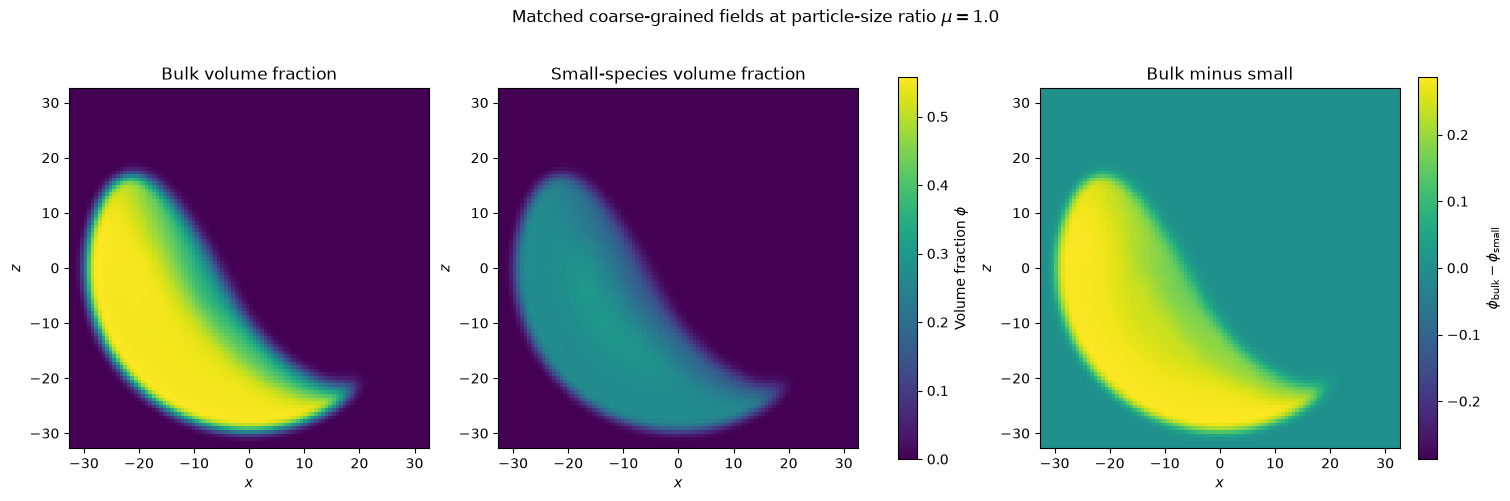

Saved representative comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_bulk_small_representative_comparison.pdf


In [9]:
import matplotlib.pyplot as plt


number_of_x_points = x_values.size
number_of_z_points = z_values.size


def vector_to_xz_field(
    vector: np.ndarray,
) -> np.ndarray:
    """Convert the raw file ordering into a z-by-x image array."""
    return vector.reshape(
        number_of_x_points,
        number_of_z_points,
        order="C",
    ).T


bulk_phi_field = vector_to_xz_field(
    representative_bulk_phi
)

small_phi_field = vector_to_xz_field(
    representative_small_phi
)

difference_phi_field = vector_to_xz_field(
    representative_difference_phi
)

shared_field_maximum = max(
    bulk_phi_field.max(),
    small_phi_field.max(),
)

difference_limit = float(
    np.max(
        np.abs(
            difference_phi_field
        )
    )
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True,
)

bulk_image = axes[0].imshow(
    bulk_phi_field,
    origin="lower",
    extent=(
        x_values.min(),
        x_values.max(),
        z_values.min(),
        z_values.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=shared_field_maximum,
)

axes[0].set_title(
    "Bulk volume fraction"
)

small_image = axes[1].imshow(
    small_phi_field,
    origin="lower",
    extent=(
        x_values.min(),
        x_values.max(),
        z_values.min(),
        z_values.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=shared_field_maximum,
)

axes[1].set_title(
    "Small-species volume fraction"
)

difference_image = axes[2].imshow(
    difference_phi_field,
    origin="lower",
    extent=(
        x_values.min(),
        x_values.max(),
        z_values.min(),
        z_values.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=-difference_limit,
    vmax=difference_limit,
)

axes[2].set_title(
    "Bulk minus small"
)

for axis in axes:
    axis.set_xlabel(r"$x$")
    axis.set_ylabel(r"$z$")

field_colour_bar = figure.colorbar(
    bulk_image,
    ax=[
        axes[0],
        axes[1],
    ],
    shrink=0.82,
)

field_colour_bar.set_label(
    r"Volume fraction $\phi$"
)

difference_colour_bar = figure.colorbar(
    difference_image,
    ax=axes[2],
    shrink=0.82,
)

difference_colour_bar.set_label(
    r"$\phi_{\mathrm{bulk}}-\phi_{\mathrm{small}}$"
)

figure.suptitle(
    "Matched coarse-grained fields at "
    r"particle-size ratio $\mu=1.0$"
)

representative_comparison_figure_path = (
    FIGURE_DIR
    / "cg_phi_bulk_small_representative_comparison.pdf"
)

figure.savefig(
    representative_comparison_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved representative comparison:")
print(representative_comparison_figure_path)

Processed pair 1/100
Processed pair 20/100
Processed pair 40/100
Processed pair 60/100
Processed pair 80/100
Processed pair 100/100

All-pair bulk-small summary
---------------------------
Mean bulk integrated volume: 565.545686
Mean small integrated volume: 282.758160
Mean inferred large integrated volume: 282.787526
Bulk integrated-volume range: 565.499427 to 565.622761
Small integrated-volume range: 282.743613 to 282.798289
Large integrated-volume range: 282.744193 to 282.862722
Maximum fraction where bulk < small: 0.000000e+00
Mean active-region correlation: 0.812745


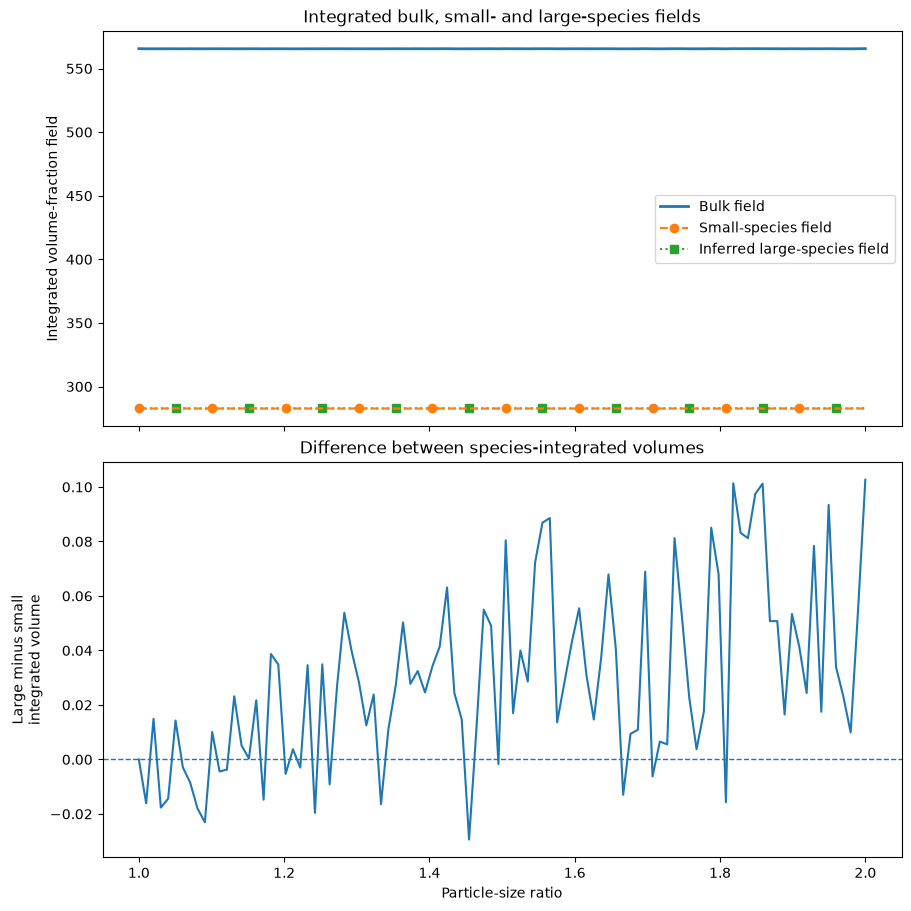


Saved all-pair comparison:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_bulk_small_pair_comparison.csv

Saved integrated-volume figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_bulk_small_integrated_volume.pdf


,size_ratio,simulation_number,bulk_mean_phi,small_mean_phi,bulk_integrated_volume,small_integrated_volume,difference_integrated_volume,inferred_large_integrated_volume,bulk_to_small_integral_ratio,minimum_bulk_minus_small,maximum_bulk_minus_small,mean_absolute_bulk_small_difference,fraction_bulk_below_small,active_region_correlation,bulk_nonzero_fraction,small_nonzero_fraction
0,1.000000,1,0.129843,0.064922,565.596567,282.798289,282.798278,282.798278,2.000000,0.0,0.286867,0.064922,0.0,0.996841,0.4194,0.4118
1,1.010101,2,0.129826,0.064915,565.524009,282.770049,282.753960,282.753960,1.999943,0.0,0.299254,0.064911,0.0,0.994277,0.4159,0.4139
2,1.020202,3,0.129827,0.064912,565.528018,282.756558,282.771460,282.771460,2.000053,0.0,0.302249,0.064915,0.0,0.991596,0.4150,0.4102
3,1.030303,4,0.129826,0.064915,565.523048,282.770364,282.752685,282.752685,1.999937,0.0,0.299102,0.064911,0.0,0.992392,0.4233,0.4213
4,1.040404,5,0.129833,0.064918,565.550724,282.782548,282.768176,282.768176,1.999949,0.0,0.306465,0.064915,0.0,0.985342,0.4158,0.4129
5,1.050505,6,0.129830,0.064913,565.538021,282.761867,282.776154,282.776154,2.000051,0.0,0.314993,0.064916,0.0,0.982546,0.4341,0.4314
6,1.060606,7,0.129825,0.064913,565.515858,282.759384,282.756473,282.756473,1.999990,0.0,0.314916,0.064912,0.0,0.977290,0.4268,0.4149
7,1.070707,8,0.129836,0.064919,565.566266,282.787401,282.778865,282.778865,1.999970,0.0,0.318315,0.064917,0.0,0.972214,0.4149,0.4120
8,1.080808,9,0.129828,0.064916,565.529947,282.773990,282.755957,282.755957,1.999936,0.0,0.320916,0.064912,0.0,0.969347,0.4305,0.4172
9,1.090909,10,0.129828,0.064917,565.530639,282.776857,282.753781,282.753781,1.999918,0.0,0.326296,0.064911,0.0,0.960510,0.4224,0.4180


In [15]:
bulk_small_comparison_records = []

for pair_index in range(
    len(bulk_files)
):
    bulk_file = bulk_files[
        pair_index
    ]

    small_file = small_files[
        pair_index
    ]

    bulk_data = load_stat_matrix(
        bulk_file,
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    small_data = load_stat_matrix(
        small_file,
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    maximum_coordinate_time_difference = float(
        np.max(
            np.abs(
                bulk_data[
                    :,
                    :3,
                ]
                - small_data[
                    :,
                    :3,
                ]
            )
        )
    )

    if maximum_coordinate_time_difference > 1e-12:
        raise ValueError(
            "Bulk and small grids do not match for "
            f"{bulk_file.name}"
        )

    bulk_phi = bulk_data[
        :,
        3,
    ]

    small_phi = small_data[
        :,
        3,
    ]

    inferred_large_phi = (
        bulk_phi
        - small_phi
    )

    active_points = (
        (np.abs(bulk_phi) > 1e-12)
        | (np.abs(small_phi) > 1e-12)
    )

    if (
        active_points.sum() > 1
        and np.std(
            bulk_phi[
                active_points
            ]
        ) > 0.0
        and np.std(
            small_phi[
                active_points
            ]
        ) > 0.0
    ):
        active_correlation = float(
            np.corrcoef(
                bulk_phi[
                    active_points
                ],
                small_phi[
                    active_points
                ],
            )[0, 1]
        )
    else:
        active_correlation = np.nan

    bulk_integral = float(
        bulk_phi.sum()
        * cell_area
    )

    small_integral = float(
        small_phi.sum()
        * cell_area
    )

    inferred_large_integral = float(
        inferred_large_phi.sum()
        * cell_area
    )

    bulk_small_comparison_records.append(
        {
            "size_ratio": float(
                bulk_parameters[
                    pair_index
                ]
            ),
            "simulation_number": int(
                bulk_simulation_numbers[
                    pair_index
                ]
            ),
            "bulk_mean_phi": float(
                bulk_phi.mean()
            ),
            "small_mean_phi": float(
                small_phi.mean()
            ),
            "bulk_integrated_volume": (
                bulk_integral
            ),
            "small_integrated_volume": (
                small_integral
            ),
            "difference_integrated_volume": (
                inferred_large_integral
            ),
            "inferred_large_integrated_volume": (
                inferred_large_integral
            ),
            "bulk_to_small_integral_ratio": (
                bulk_integral
                / small_integral
            ),
            "minimum_bulk_minus_small": float(
                inferred_large_phi.min()
            ),
            "maximum_bulk_minus_small": float(
                inferred_large_phi.max()
            ),
            "mean_absolute_bulk_small_difference": float(
                np.mean(
                    np.abs(
                        inferred_large_phi
                    )
                )
            ),
            "fraction_bulk_below_small": float(
                np.mean(
                    bulk_phi
                    < small_phi - 1e-10
                )
            ),
            "active_region_correlation": (
                active_correlation
            ),
            "bulk_nonzero_fraction": float(
                np.mean(
                    bulk_phi > 1e-12
                )
            ),
            "small_nonzero_fraction": float(
                np.mean(
                    small_phi > 1e-12
                )
            ),
        }
    )

    if (
        pair_index == 0
        or (pair_index + 1) % 20 == 0
    ):
        print(
            "Processed pair "
            f"{pair_index + 1}/"
            f"{len(bulk_files)}"
        )


bulk_small_comparison = pd.DataFrame(
    bulk_small_comparison_records
)

print("\nAll-pair bulk-small summary")
print("---------------------------")

print(
    "Mean bulk integrated volume:",
    f"{bulk_small_comparison[
        'bulk_integrated_volume'
    ].mean():.6f}",
)

print(
    "Mean small integrated volume:",
    f"{bulk_small_comparison[
        'small_integrated_volume'
    ].mean():.6f}",
)

print(
    "Mean inferred large integrated volume:",
    f"{bulk_small_comparison[
        'inferred_large_integrated_volume'
    ].mean():.6f}",
)

print(
    "Bulk integrated-volume range:",
    f"{bulk_small_comparison[
        'bulk_integrated_volume'
    ].min():.6f}",
    "to",
    f"{bulk_small_comparison[
        'bulk_integrated_volume'
    ].max():.6f}",
)

print(
    "Small integrated-volume range:",
    f"{bulk_small_comparison[
        'small_integrated_volume'
    ].min():.6f}",
    "to",
    f"{bulk_small_comparison[
        'small_integrated_volume'
    ].max():.6f}",
)

print(
    "Large integrated-volume range:",
    f"{bulk_small_comparison[
        'inferred_large_integrated_volume'
    ].min():.6f}",
    "to",
    f"{bulk_small_comparison[
        'inferred_large_integrated_volume'
    ].max():.6f}",
)

print(
    "Maximum fraction where bulk < small:",
    f"{bulk_small_comparison[
        'fraction_bulk_below_small'
    ].max():.6e}",
)

print(
    "Mean active-region correlation:",
    f"{bulk_small_comparison[
        'active_region_correlation'
    ].mean():.6f}",
)


bulk_small_comparison_path = (
    TABLE_DIR
    / "cg_phi_bulk_small_pair_comparison.csv"
)

bulk_small_comparison.to_csv(
    bulk_small_comparison_path,
    index=False,
)


size_ratios = bulk_small_comparison[
    "size_ratio"
]

bulk_integrated_volume = (
    bulk_small_comparison[
        "bulk_integrated_volume"
    ]
)

small_integrated_volume = (
    bulk_small_comparison[
        "small_integrated_volume"
    ]
)

inferred_large_integrated_volume = (
    bulk_small_comparison[
        "inferred_large_integrated_volume"
    ]
)

large_minus_small_integral = (
    inferred_large_integrated_volume
    - small_integrated_volume
)


figure, axes = plt.subplots(
    2,
    1,
    figsize=(9, 9),
    sharex=True,
    constrained_layout=True,
)

axes[0].plot(
    size_ratios,
    bulk_integrated_volume,
    linewidth=2,
    label="Bulk field",
)

axes[0].plot(
    size_ratios,
    small_integrated_volume,
    linestyle="--",
    marker="o",
    markevery=(0, 10),
    label="Small-species field",
    zorder=3,
)

axes[0].plot(
    size_ratios,
    inferred_large_integrated_volume,
    linestyle=":",
    marker="s",
    markevery=(5, 10),
    label="Inferred large-species field",
    zorder=2,
)

axes[0].set_ylabel(
    "Integrated volume-fraction field"
)

axes[0].set_title(
    "Integrated bulk, small- and large-species fields"
)

axes[0].legend()


axes[1].plot(
    size_ratios,
    large_minus_small_integral,
)

axes[1].axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

axes[1].set_xlabel(
    "Particle-size ratio"
)

axes[1].set_ylabel(
    "Large minus small\nintegrated volume"
)

axes[1].set_title(
    "Difference between species-integrated volumes"
)


integrated_volume_figure_path = (
    FIGURE_DIR
    / "cg_phi_bulk_small_integrated_volume.pdf"
)

figure.savefig(
    integrated_volume_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved all-pair comparison:")
print(bulk_small_comparison_path)

print("\nSaved integrated-volume figure:")
print(integrated_volume_figure_path)

display(
    bulk_small_comparison.head(10)
)

In [16]:
large_species_filename_pattern = re.compile(
    r"rotating_drum_bidisperse_"
    r"size_ratio_"
    r"(?P<integer>\d+)_"
    r"(?P<fraction>\d+)_"
    r"num_"
    r"(?P<simulation_number>\d+)"
    r"\.largeSpecies\.stat"
)


def parse_large_species_filename(
    file_path: Path,
) -> dict:
    """Parse an explicitly supplied large-species filename."""
    match = large_species_filename_pattern.fullmatch(
        file_path.name
    )

    if match is None:
        raise ValueError(
            "Unexpected large-species filename: "
            f"{file_path.name}"
        )

    size_ratio = float(
        f"{match.group('integer')}."
        f"{match.group('fraction')}"
    )

    return {
        "size_ratio": size_ratio,
        "simulation_number": int(
            match.group(
                "simulation_number"
            )
        ),
    }


explicit_large_species_files = sorted(
    SMALL_DATA_DIR.glob(
        "*.largeSpecies.stat"
    )
)

print(
    "Explicit large-species files found:",
    len(explicit_large_species_files),
)

large_species_validation_records = []

for explicit_file in explicit_large_species_files:
    metadata = parse_large_species_filename(
        explicit_file
    )

    matching_rows = bulk_inventory.index[
        (
            bulk_inventory[
                "simulation_number"
            ]
            == metadata[
                "simulation_number"
            ]
        )
        & np.isclose(
            bulk_inventory[
                "size_ratio"
            ],
            metadata[
                "size_ratio"
            ],
            rtol=0.0,
            atol=1e-12,
        )
    ].to_numpy()

    if matching_rows.size != 1:
        raise ValueError(
            "Could not identify one matching bulk-small pair "
            f"for {explicit_file.name}"
        )

    pair_index = int(
        matching_rows[0]
    )

    bulk_data = load_stat_matrix(
        bulk_files[
            pair_index
        ],
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    small_data = load_stat_matrix(
        small_files[
            pair_index
        ],
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    explicit_large_data = load_stat_matrix(
        explicit_file,
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    maximum_grid_difference = float(
        np.max(
            np.abs(
                explicit_large_data[
                    :,
                    :3,
                ]
                - bulk_data[
                    :,
                    :3,
                ]
            )
        )
    )

    inferred_large_phi = (
        bulk_data[
            :,
            3,
        ]
        - small_data[
            :,
            3,
        ]
    )

    explicit_large_phi = (
        explicit_large_data[
            :,
            3,
        ]
    )

    absolute_difference = np.abs(
        inferred_large_phi
        - explicit_large_phi
    )

    relative_field_error = float(
        np.linalg.norm(
            inferred_large_phi
            - explicit_large_phi
        )
        / np.linalg.norm(
            explicit_large_phi
        )
    )

    large_species_validation_records.append(
        {
            "filename": explicit_file.name,
            "size_ratio": metadata[
                "size_ratio"
            ],
            "simulation_number": metadata[
                "simulation_number"
            ],
            "maximum_grid_difference": (
                maximum_grid_difference
            ),
            "mean_absolute_field_difference": float(
                absolute_difference.mean()
            ),
            "maximum_absolute_field_difference": float(
                absolute_difference.max()
            ),
            "relative_field_error": (
                relative_field_error
            ),
            "explicit_integrated_volume": float(
                explicit_large_phi.sum()
                * cell_area
            ),
            "inferred_integrated_volume": float(
                inferred_large_phi.sum()
                * cell_area
            ),
        }
    )


large_species_validation = pd.DataFrame(
    large_species_validation_records
)

if large_species_validation.empty:
    explicit_validation_passed = False

    print(
        "\nNo explicit large-species file was available "
        "for direct validation."
    )

else:
    print(
        "\nExplicit large-species validation:"
    )

    display(
        large_species_validation
    )

    # The separately saved stat files contain rounded decimal values.
    # A tolerance of 1e-5 allows for this text-output precision while
    # remaining far smaller than the physical field magnitudes.
    explicit_validation_passed = bool(
        (
            large_species_validation[
                "maximum_grid_difference"
            ]
            < 1e-12
        ).all()
        and (
            large_species_validation[
                "relative_field_error"
            ]
            < 1e-5
        ).all()
        and (
            large_species_validation[
                "maximum_absolute_field_difference"
            ]
            < 5e-6
        ).all()
    )

    print(
        "Bulk-minus-small matches the explicit "
        "large-species field within saved-data precision:",
        explicit_validation_passed,
    )

    validation_path = (
        TABLE_DIR
        / "cg_phi_explicit_large_species_validation.csv"
    )

    large_species_validation.to_csv(
        validation_path,
        index=False,
    )

    print("\nSaved validation table:")
    print(validation_path)

Explicit large-species files found: 1

Explicit large-species validation:


,filename,size_ratio,simulation_number,maximum_grid_difference,mean_absolute_field_difference,maximum_absolute_field_difference,relative_field_error,explicit_integrated_volume,inferred_integrated_volume
0,rotating_drum_bidisperse_size_ratio_1_808081_n...,1.808081,81,0.0,8.589509e-08,0.000001,0.000002,282.744596,282.744605


Bulk-minus-small matches the explicit large-species field within saved-data precision: True

Saved validation table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_explicit_large_species_validation.csv


In [17]:
number_of_grid_points = (
    representative_bulk_matrix.shape[0]
)

number_of_simulations = len(
    bulk_files
)

bulk_snapshot_matrix = np.empty(
    (
        number_of_grid_points,
        number_of_simulations,
    ),
    dtype=float,
)

small_snapshot_matrix = np.empty_like(
    bulk_snapshot_matrix
)

reference_time_and_coordinates = (
    representative_bulk_matrix[
        :,
        :3,
    ]
)

for simulation_index in range(
    number_of_simulations
):
    bulk_data = load_stat_matrix(
        bulk_files[
            simulation_index
        ],
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    small_data = load_stat_matrix(
        small_files[
            simulation_index
        ],
        usecols=(
            0,
            1,
            2,
            3,
        ),
    )

    bulk_grid_difference = np.max(
        np.abs(
            bulk_data[
                :,
                :3,
            ]
            - reference_time_and_coordinates
        )
    )

    small_grid_difference = np.max(
        np.abs(
            small_data[
                :,
                :3,
            ]
            - reference_time_and_coordinates
        )
    )

    if (
        bulk_grid_difference > 1e-12
        or small_grid_difference > 1e-12
    ):
        raise ValueError(
            "Inconsistent time or grid in simulation "
            f"{simulation_index + 1}."
        )

    bulk_snapshot_matrix[
        :,
        simulation_index,
    ] = bulk_data[
        :,
        3,
    ]

    small_snapshot_matrix[
        :,
        simulation_index,
    ] = small_data[
        :,
        3,
    ]

    if (
        simulation_index == 0
        or (simulation_index + 1) % 20 == 0
    ):
        print(
            "Loaded simulation "
            f"{simulation_index + 1}/"
            f"{number_of_simulations}"
        )


large_snapshot_matrix = (
    bulk_snapshot_matrix
    - small_snapshot_matrix
)

minimum_large_value = float(
    large_snapshot_matrix.min()
)

fraction_large_below_minus_1e_10 = float(
    np.mean(
        large_snapshot_matrix
        < -1e-10
    )
)

bulk_integrated_volumes = (
    bulk_snapshot_matrix.sum(
        axis=0
    )
    * cell_area
)

small_integrated_volumes = (
    small_snapshot_matrix.sum(
        axis=0
    )
    * cell_area
)

large_integrated_volumes = (
    large_snapshot_matrix.sum(
        axis=0
    )
    * cell_area
)

print("\nSnapshot matrices")
print("-----------------")

print(
    "Bulk snapshots:",
    bulk_snapshot_matrix.shape,
)

print(
    "Small snapshots:",
    small_snapshot_matrix.shape,
)

print(
    "Large snapshots:",
    large_snapshot_matrix.shape,
)

print(
    "Minimum inferred large-species value:",
    f"{minimum_large_value:.6e}",
)

print(
    "Fraction of inferred values below -1e-10:",
    f"{fraction_large_below_minus_1e_10:.6e}",
)

print(
    "Mean bulk integrated volume:",
    f"{bulk_integrated_volumes.mean():.6f}",
)

print(
    "Mean small integrated volume:",
    f"{small_integrated_volumes.mean():.6f}",
)

print(
    "Mean large integrated volume:",
    f"{large_integrated_volumes.mean():.6f}",
)

assert bulk_snapshot_matrix.shape == (
    10000,
    100,
)

assert small_snapshot_matrix.shape == (
    10000,
    100,
)

assert large_snapshot_matrix.shape == (
    10000,
    100,
)

assert fraction_large_below_minus_1e_10 == 0.0

processed_dataset_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "cg_phi_bulk_small_large_dataset.npz"
)

np.savez_compressed(
    processed_dataset_path,
    x=x_values,
    z=z_values,
    time=bulk_times,
    parameters=bulk_parameters,
    simulation_numbers=(
        bulk_simulation_numbers
    ),
    bulk_snapshots=(
        bulk_snapshot_matrix
    ),
    small_snapshots=(
        small_snapshot_matrix
    ),
    large_snapshots=(
        large_snapshot_matrix
    ),
)

combined_memory_mb = (
    bulk_snapshot_matrix.nbytes
    + small_snapshot_matrix.nbytes
    + large_snapshot_matrix.nbytes
) / 1024**2

print(
    "\nIn-memory size of the three matrices:",
    f"{combined_memory_mb:.2f} MB",
)

print(
    "Saved processed file size:",
    f"{processed_dataset_path.stat().st_size / 1024**2:.2f} MB",
)

print("\nSaved processed paired dataset:")
print(processed_dataset_path)

Loaded simulation 1/100
Loaded simulation 20/100
Loaded simulation 40/100
Loaded simulation 60/100
Loaded simulation 80/100
Loaded simulation 100/100

Snapshot matrices
-----------------
Bulk snapshots: (10000, 100)
Small snapshots: (10000, 100)
Large snapshots: (10000, 100)
Minimum inferred large-species value: 0.000000e+00
Fraction of inferred values below -1e-10: 0.000000e+00
Mean bulk integrated volume: 565.545686
Mean small integrated volume: 282.758160
Mean large integrated volume: 282.787526

In-memory size of the three matrices: 22.89 MB
Saved processed file size: 8.53 MB

Saved processed paired dataset:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_bulk_small_large_dataset.npz


Segregation diagnostics
-----------------------
L1-separation range: 0.040773 to 0.576262
Overlap-fraction range: 0.423815 to 0.959227
Correlation range: -0.002532 to 0.987083
Centre-separation range: 0.182516 to 1.632228


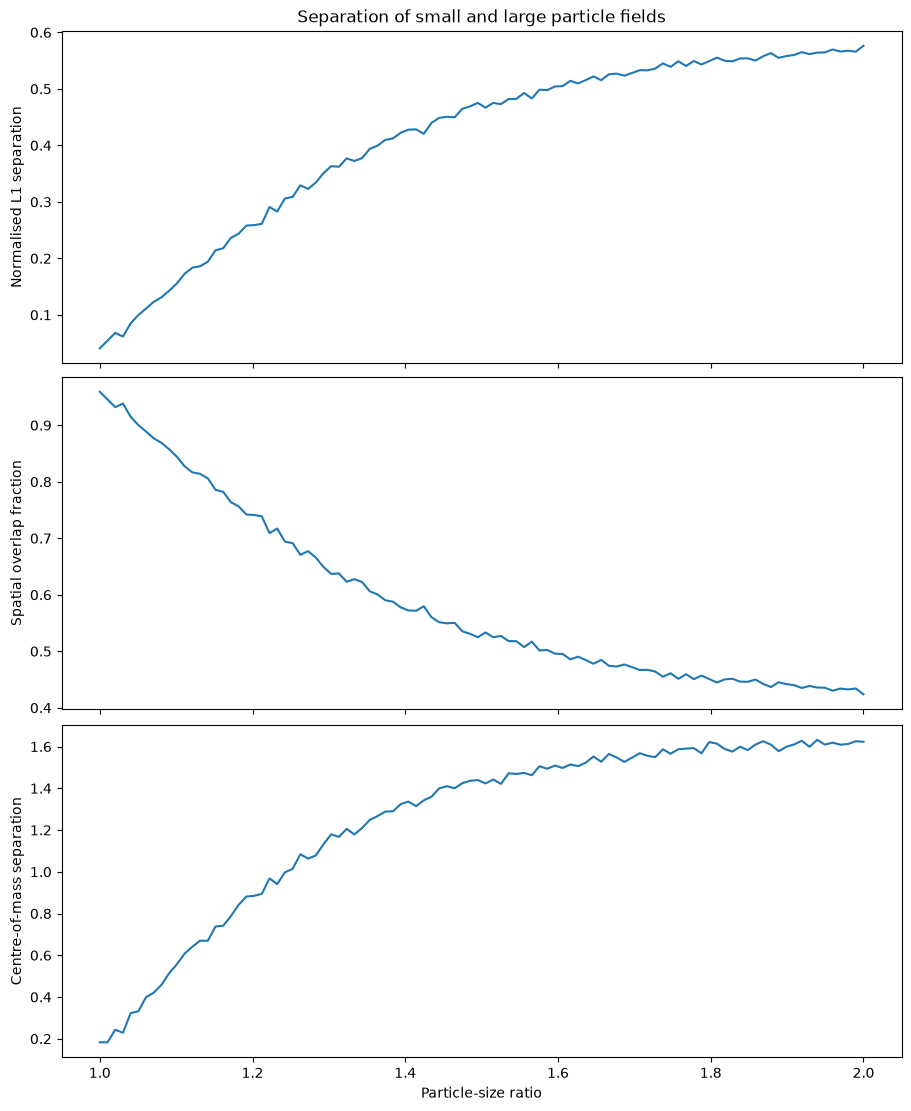


Saved segregation diagnostics:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_species_segregation_diagnostics.csv

Saved segregation figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_species_segregation_metrics.pdf


,size_ratio,simulation_number,normalised_l1_separation,overlap_fraction,small_large_spatial_correlation,small_centre_x,small_centre_z,large_centre_x,large_centre_z,centre_of_mass_separation
0,1.000000,1,0.040773,0.959227,0.987083,-12.202495,-10.063980,-12.245199,-10.241783,0.182860
1,1.010101,2,0.054282,0.945745,0.976845,-12.197544,-10.063132,-12.288008,-10.221650,0.182516
2,1.020202,3,0.068018,0.932007,0.965718,-12.184424,-10.021064,-12.319175,-10.223219,0.242950
3,1.030303,4,0.061644,0.938385,0.969119,-12.205803,-10.014307,-12.325795,-10.208915,0.228627
4,1.040404,5,0.084963,0.915060,0.940337,-12.210285,-9.972183,-12.326755,-10.273158,0.322724
5,1.050505,6,0.099727,0.900296,0.928869,-12.185753,-9.964963,-12.331196,-10.262797,0.331450
6,1.060606,7,0.111208,0.888796,0.908003,-12.204846,-9.894514,-12.375107,-10.255572,0.399189
7,1.070707,8,0.123205,0.876808,0.886687,-12.187350,-9.911070,-12.358690,-10.295622,0.420996
8,1.080808,9,0.131190,0.868838,0.876386,-12.182313,-9.886221,-12.377575,-10.300671,0.458144
9,1.090909,10,0.142733,0.857302,0.840769,-12.194887,-9.827172,-12.406751,-10.295783,0.514279


In [18]:
x_coordinates = (
    reference_time_and_coordinates[
        :,
        1,
    ]
)

z_coordinates = (
    reference_time_and_coordinates[
        :,
        2,
    ]
)

segregation_records = []

for simulation_index, parameter in enumerate(
    bulk_parameters
):
    bulk_phi = bulk_snapshot_matrix[
        :,
        simulation_index,
    ]

    small_phi = small_snapshot_matrix[
        :,
        simulation_index,
    ]

    large_phi = large_snapshot_matrix[
        :,
        simulation_index,
    ]

    bulk_integral = (
        bulk_integrated_volumes[
            simulation_index
        ]
    )

    small_integral = (
        small_integrated_volumes[
            simulation_index
        ]
    )

    large_integral = (
        large_integrated_volumes[
            simulation_index
        ]
    )

    normalised_l1_separation = float(
        np.sum(
            np.abs(
                small_phi
                - large_phi
            )
        )
        * cell_area
        / bulk_integral
    )

    overlap_integral = float(
        np.minimum(
            small_phi,
            large_phi,
        ).sum()
        * cell_area
    )

    overlap_fraction = float(
        overlap_integral
        / min(
            small_integral,
            large_integral,
        )
    )

    small_centre_x = float(
        np.sum(
            x_coordinates
            * small_phi
        )
        * cell_area
        / small_integral
    )

    small_centre_z = float(
        np.sum(
            z_coordinates
            * small_phi
        )
        * cell_area
        / small_integral
    )

    large_centre_x = float(
        np.sum(
            x_coordinates
            * large_phi
        )
        * cell_area
        / large_integral
    )

    large_centre_z = float(
        np.sum(
            z_coordinates
            * large_phi
        )
        * cell_area
        / large_integral
    )

    centre_separation = float(
        np.hypot(
            small_centre_x
            - large_centre_x,
            small_centre_z
            - large_centre_z,
        )
    )

    active_mask = (
        (small_phi > 1e-12)
        | (large_phi > 1e-12)
    )

    spatial_correlation = float(
        np.corrcoef(
            small_phi[
                active_mask
            ],
            large_phi[
                active_mask
            ],
        )[0, 1]
    )

    segregation_records.append(
        {
            "size_ratio": float(
                parameter
            ),
            "simulation_number": int(
                bulk_simulation_numbers[
                    simulation_index
                ]
            ),
            "normalised_l1_separation": (
                normalised_l1_separation
            ),
            "overlap_fraction": (
                overlap_fraction
            ),
            "small_large_spatial_correlation": (
                spatial_correlation
            ),
            "small_centre_x": (
                small_centre_x
            ),
            "small_centre_z": (
                small_centre_z
            ),
            "large_centre_x": (
                large_centre_x
            ),
            "large_centre_z": (
                large_centre_z
            ),
            "centre_of_mass_separation": (
                centre_separation
            ),
        }
    )


segregation_diagnostics = pd.DataFrame(
    segregation_records
)

print("Segregation diagnostics")
print("-----------------------")

print(
    "L1-separation range:",
    f"{segregation_diagnostics[
        'normalised_l1_separation'
    ].min():.6f}",
    "to",
    f"{segregation_diagnostics[
        'normalised_l1_separation'
    ].max():.6f}",
)

print(
    "Overlap-fraction range:",
    f"{segregation_diagnostics[
        'overlap_fraction'
    ].min():.6f}",
    "to",
    f"{segregation_diagnostics[
        'overlap_fraction'
    ].max():.6f}",
)

print(
    "Correlation range:",
    f"{segregation_diagnostics[
        'small_large_spatial_correlation'
    ].min():.6f}",
    "to",
    f"{segregation_diagnostics[
        'small_large_spatial_correlation'
    ].max():.6f}",
)

print(
    "Centre-separation range:",
    f"{segregation_diagnostics[
        'centre_of_mass_separation'
    ].min():.6f}",
    "to",
    f"{segregation_diagnostics[
        'centre_of_mass_separation'
    ].max():.6f}",
)

segregation_path = (
    TABLE_DIR
    / "cg_phi_species_segregation_diagnostics.csv"
)

segregation_diagnostics.to_csv(
    segregation_path,
    index=False,
)


figure, axes = plt.subplots(
    3,
    1,
    figsize=(9, 11),
    sharex=True,
    constrained_layout=True,
)

axes[0].plot(
    segregation_diagnostics[
        "size_ratio"
    ],
    segregation_diagnostics[
        "normalised_l1_separation"
    ],
)

axes[0].set_ylabel(
    "Normalised L1 separation"
)

axes[0].set_title(
    "Separation of small and large particle fields"
)

axes[1].plot(
    segregation_diagnostics[
        "size_ratio"
    ],
    segregation_diagnostics[
        "overlap_fraction"
    ],
)

axes[1].set_ylabel(
    "Spatial overlap fraction"
)

axes[2].plot(
    segregation_diagnostics[
        "size_ratio"
    ],
    segregation_diagnostics[
        "centre_of_mass_separation"
    ],
)

axes[2].set_ylabel(
    "Centre-of-mass separation"
)

axes[2].set_xlabel(
    "Particle-size ratio"
)

segregation_figure_path = (
    FIGURE_DIR
    / "cg_phi_species_segregation_metrics.pdf"
)

figure.savefig(
    segregation_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved segregation diagnostics:")
print(segregation_path)

print("\nSaved segregation figure:")
print(segregation_figure_path)

display(
    segregation_diagnostics.head(10)
)

In [19]:
from IPython.display import Markdown


inventory_summary = pd.DataFrame(
    [
        {
            "number_of_simulations": (
                number_of_simulations
            ),
            "grid_points_per_field": (
                number_of_grid_points
            ),
            "number_of_x_points": (
                x_values.size
            ),
            "number_of_z_points": (
                z_values.size
            ),
            "parameter_minimum": (
                bulk_parameters.min()
            ),
            "parameter_maximum": (
                bulk_parameters.max()
            ),
            "mean_bulk_integrated_volume": (
                bulk_integrated_volumes.mean()
            ),
            "mean_small_integrated_volume": (
                small_integrated_volumes.mean()
            ),
            "mean_large_integrated_volume": (
                large_integrated_volumes.mean()
            ),
            "minimum_large_value": (
                minimum_large_value
            ),
            "explicit_large_validation_passed": (
                explicit_validation_passed
            ),
            "minimum_overlap_fraction": (
                segregation_diagnostics[
                    "overlap_fraction"
                ].min()
            ),
            "maximum_centre_separation": (
                segregation_diagnostics[
                    "centre_of_mass_separation"
                ].max()
            ),
            "processed_file_size_mb": (
                processed_dataset_path.stat().st_size
                / 1024**2
            ),
        }
    ]
)

inventory_summary_path = (
    TABLE_DIR
    / "cg_phi_bulk_inventory_summary.csv"
)

inventory_summary.to_csv(
    inventory_summary_path,
    index=False,
)

display(
    inventory_summary
)


inventory_conclusion = f"""
## Conclusions

The supplied bulk dataset contains 100 MercuryCG files covering particle-size
ratios from {bulk_parameters.min():.1f} to
{bulk_parameters.max():.1f}. Every bulk file has an exact one-to-one match
with a file in the previously analysed small-species dataset.

Both datasets use the same time-averaged 100-by-100 XZ grid, the same
10,000 spatial points, the same output time and the same 32-column MercuryCG
format. The word *bulk* therefore does not refer to a larger spatial grid or a
larger number of simulations.

The numerical results establish the decomposition

$$
\\phi_{{\\mathrm{{bulk}}}}
=
\\phi_{{\\mathrm{{small}}}}
+
\\phi_{{\\mathrm{{large}}}}.
$$

The inferred large-species field is non-negative across all supplied
simulations. The mean integrated volumes are approximately:

- {bulk_integrated_volumes.mean():.6f} for the bulk field;
- {small_integrated_volumes.mean():.6f} for the small-species field;
- {large_integrated_volumes.mean():.6f} for the large-species field.

The small and large species therefore contain approximately equal total solid
volumes. Their spatial distributions become increasingly different as the
particle-size ratio increases, which is consistent with size-driven
segregation in the rotating drum.

A processed dataset containing the paired bulk, small and inferred
large-species snapshot matrices has been saved for subsequent reduced-order
modelling. The three matrices have shapes
`{bulk_snapshot_matrix.shape}` and share the same parameter and spatial grids.

This bulk dataset is a different physical output from the same 100 underlying
simulations. It can therefore be used to study transfer of the ROM methodology
to bulk and large-species fields, but it is not an independent external test
set for the previously fitted small-species ROM.
"""

display(
    Markdown(
        inventory_conclusion
    )
)

inventory_conclusion_path = (
    TABLE_DIR
    / "cg_phi_bulk_inventory_conclusions.md"
)

inventory_conclusion_path.write_text(
    inventory_conclusion.strip()
    + "\n",
    encoding="utf-8",
)

print("\nSaved inventory summary:")
print(inventory_summary_path)

print("\nSaved inventory conclusions:")
print(inventory_conclusion_path)

,number_of_simulations,grid_points_per_field,number_of_x_points,number_of_z_points,parameter_minimum,parameter_maximum,mean_bulk_integrated_volume,mean_small_integrated_volume,mean_large_integrated_volume,minimum_large_value,explicit_large_validation_passed,minimum_overlap_fraction,maximum_centre_separation,processed_file_size_mb
0,100,10000,100,100,1.0,2.0,565.545686,282.75816,282.787526,0.0,True,0.423815,1.632228,8.534094



## Conclusions

The supplied bulk dataset contains 100 MercuryCG files covering particle-size
ratios from 1.0 to
2.0. Every bulk file has an exact one-to-one match
with a file in the previously analysed small-species dataset.

Both datasets use the same time-averaged 100-by-100 XZ grid, the same
10,000 spatial points, the same output time and the same 32-column MercuryCG
format. The word *bulk* therefore does not refer to a larger spatial grid or a
larger number of simulations.

The numerical results establish the decomposition

$$
\phi_{\mathrm{bulk}}
=
\phi_{\mathrm{small}}
+
\phi_{\mathrm{large}}.
$$

The inferred large-species field is non-negative across all supplied
simulations. The mean integrated volumes are approximately:

- 565.545686 for the bulk field;
- 282.758160 for the small-species field;
- 282.787526 for the large-species field.

The small and large species therefore contain approximately equal total solid
volumes. Their spatial distributions become increasingly different as the
particle-size ratio increases, which is consistent with size-driven
segregation in the rotating drum.

A processed dataset containing the paired bulk, small and inferred
large-species snapshot matrices has been saved for subsequent reduced-order
modelling. The three matrices have shapes
`(10000, 100)` and share the same parameter and spatial grids.

This bulk dataset is a different physical output from the same 100 underlying
simulations. It can therefore be used to study transfer of the ROM methodology
to bulk and large-species fields, but it is not an independent external test
set for the previously fitted small-species ROM.



Saved inventory summary:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_bulk_inventory_summary.csv

Saved inventory conclusions:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_bulk_inventory_conclusions.md
